# Análisis Exploratorio de Datos - Customer Churn

En este notebook se realiza un análisis exploratorio del dataset histórico de clientes.
El objetivo es conocer la estructura de los datos, analizar la variable objetivo Churn,
detectar valores faltantes y observar las principales características antes de entrenar los modelos.

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("../data/customer_churn_historical.csv")

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,6684-LWVH,Male,0,No,No,4,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,27.56,107.47,No
1,7027-JIFO,Male,0,No,No,35,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,30.52,1020.47,No
2,5981-VOQO,Female,0,No,No,45,Yes,Yes,DSL,No,...,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),66.87,2686.35,No
3,7266-HYDM,Male,0,Yes,No,31,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),86.95,2536.96,Yes
4,2821-JDLS,Female,0,Yes,No,5,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,30.18,139.12,No


## Estructura general del dataset

Primero se revisan las dimensiones, columnas y tipos de datos para conocer la estructura general del dataset.

In [7]:
df.shape

(7043, 21)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Observaciones iniciales

El dataset contiene 7043 registros y 21 columnas.

La mayoría de las variables son categóricas. También existen variables numéricas como tenure, MonthlyCharges y TotalCharges.

Se encontraron 26 valores faltantes en TotalCharges, ya que esta variable tiene 7017 registros no nulos sobre un total de 7043.

La variable customerID funciona como identificador del cliente, por lo que no será utilizada posteriormente como variable predictora.

La variable objetivo del proyecto es Churn.

In [9]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        26
Churn                0
dtype: int64

## Análisis de la variable objetivo

Se analiza la distribución de la variable Churn para conocer la proporción de clientes que abandonaron y que permanecieron en la empresa.

In [10]:
df["Churn"].value_counts()

Churn
No     5186
Yes    1857
Name: count, dtype: int64

In [11]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.633395
Yes    26.366605
Name: proportion, dtype: float64

### Observación

La variable Churn presenta un desbalance entre sus clases. Aproximadamente el 74% de los clientes no abandonó la empresa, mientras que alrededor del 26% sí lo hizo.

Por este motivo, la accuracy no será suficiente por sí sola para evaluar los modelos, ya que un modelo que predijera siempre la clase mayoritaria podría obtener una accuracy relativamente alta sin identificar correctamente a los clientes que abandonan.

## Análisis de variables categóricas

Se revisan los valores posibles de las variables categóricas para conocer cómo están representadas y detectar posibles categorías o valores inesperados.

In [12]:
df["Contract"].value_counts()

Contract
Month-to-month    3811
Two year          1716
One year          1516
Name: count, dtype: int64

In [13]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3165
DSL            2329
No             1549
Name: count, dtype: int64

In [14]:
df["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2386
Bank transfer (automatic)    1629
Mailed check                 1587
Credit card (automatic)      1441
Name: count, dtype: int64

In [15]:
pd.crosstab(df["Contract"], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2335,1476
One year,1289,227
Two year,1562,154


In [16]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,61.270008,38.729992
One year,85.026385,14.973615
Two year,91.025641,8.974359


### Observación

Se observa una relación entre el tipo de contrato y el Churn.

Los clientes con contrato mensual presentan la mayor proporción de abandono, con aproximadamente un 38,7%. En cambio, el Churn disminuye a aproximadamente 15% para los contratos de un año y 9% para los contratos de dos años.

Esto sugiere que los clientes con contratos de mayor duración presentan una menor proporción de abandono.

In [17]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,80.034350,19.965650
Fiber optic,59.747235,40.252765
No,92.382182,7.617818


### Observación

Se observan diferencias en la proporción de Churn según el tipo de servicio de Internet.

Los clientes con fibra óptica presentan la mayor proporción de abandono, con aproximadamente un 40,3%. Los clientes con DSL presentan aproximadamente un 20%, mientras que los clientes sin servicio de Internet tienen una proporción de Churn cercana al 7,6%.

Esto sugiere que el tipo de servicio de Internet podría ser una variable relevante para predecir el Churn.

In [18]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),76.979742,23.020258
Credit card (automatic),75.433727,24.566273
Electronic check,68.943839,31.056161
Mailed check,75.614367,24.385633


### Observación

El método de pago con mayor proporción de Churn es Electronic check, con aproximadamente un 31%.

En los demás métodos de pago la proporción de abandono es bastante similar, ya que se encuentra aproximadamente entre el 23% y el 25%.

La diferencia entre los métodos de pago es menor que la observada anteriormente en variables como Contract e InternetService.

## Análisis de variables numéricas

Se analizan las principales variables numéricas del dataset para conocer su distribución, valores mínimos, máximos y medidas centrales.

In [19]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7017.000000
mean,35.168394,68.168503,2312.077586
std,18.901478,24.980659,1573.967858
min,0.000000,18.000000,0.000000
25%,20.000000,55.360000,986.630000
50%,35.000000,73.910000,2013.200000
75%,51.000000,88.000000,3452.850000
max,72.000000,114.410000,7761.340000


In [20]:
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,37.278249,63.940046,2324.697043
Yes,29.276252,79.977216,2276.805895


### Observación

Al comparar las variables numéricas según Churn, se observa que los clientes que abandonaron tenían una antigüedad promedio menor, de aproximadamente 29 meses, frente a 37 meses entre quienes permanecieron.

También se observa una diferencia en MonthlyCharges. Los clientes que abandonaron pagaban en promedio aproximadamente 80 por mes, mientras que quienes permanecieron pagaban cerca de 64.

En TotalCharges los promedios son similares entre ambos grupos, por lo que a partir de esta comparación no se observa una diferencia tan marcada.

## Visualizaciones al EDA

In [21]:
import matplotlib.pyplot as plt

## Distribución de variables numéricas según Churn

Se comparan gráficamente algunas variables numéricas para observar posibles diferencias entre los clientes que permanecieron y los que abandonaron.

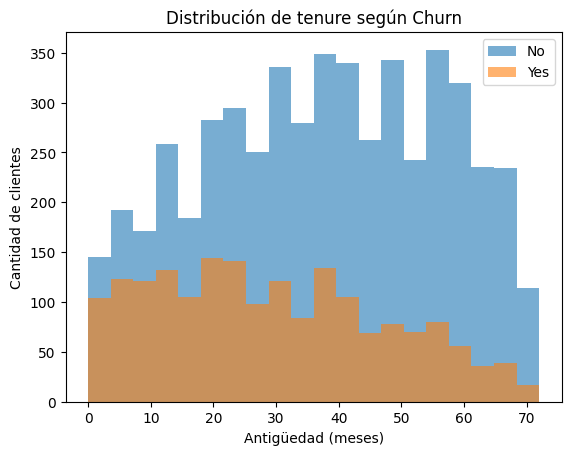

In [22]:
plt.hist(df[df["Churn"] == "No"]["tenure"], bins=20, alpha=0.6, label="No")
plt.hist(df[df["Churn"] == "Yes"]["tenure"], bins=20, alpha=0.6, label="Yes")

plt.xlabel("Antigüedad (meses)")
plt.ylabel("Cantidad de clientes")
plt.title("Distribución de tenure según Churn")
plt.legend()

plt.show()

### Observación

La distribución muestra que los clientes que abandonaron tienden a concentrarse más en niveles de antigüedad bajos y medios, mientras que entre los clientes que permanecieron hay una mayor presencia de antigüedades medias y altas.

Esto coincide con lo observado anteriormente en los promedios de tenure y sugiere que la antigüedad del cliente podría ser una variable relevante para predecir el Churn.

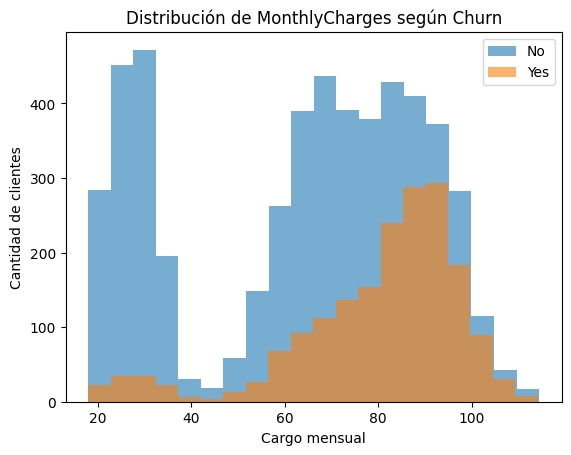

In [23]:
plt.hist(df[df["Churn"] == "No"]["MonthlyCharges"], bins=20, alpha=0.6, label="No")
plt.hist(df[df["Churn"] == "Yes"]["MonthlyCharges"], bins=20, alpha=0.6, label="Yes")

plt.xlabel("Cargo mensual")
plt.ylabel("Cantidad de clientes")
plt.title("Distribución de MonthlyCharges según Churn")
plt.legend()

plt.show()

### Observación

Se observa que los clientes que abandonaron presentan una mayor concentración en valores altos de MonthlyCharges.

Esto coincide con el análisis de los promedios, donde los clientes con Churn tenían un cargo mensual promedio mayor que aquellos que permanecieron.

Por lo tanto, MonthlyCharges podría ser una variable relevante para la predicción del Churn.

In [24]:
churn_contract = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

churn_contract

Churn,No,Yes
Contract,,
Month-to-month,61.270008,38.729992
One year,85.026385,14.973615
Two year,91.025641,8.974359


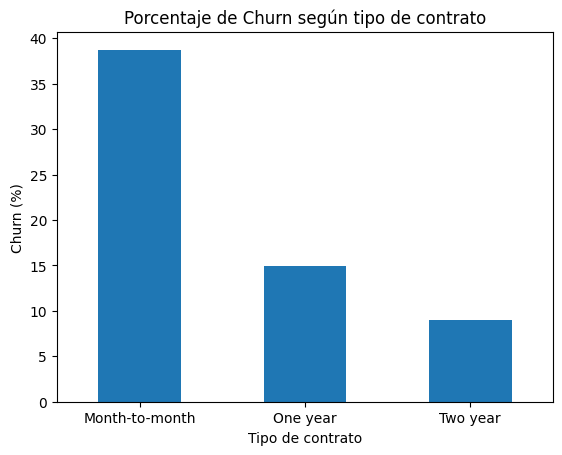

In [25]:
churn_contract["Yes"].plot(kind="bar")

plt.xlabel("Tipo de contrato")
plt.ylabel("Churn (%)")
plt.title("Porcentaje de Churn según tipo de contrato")
plt.xticks(rotation=0)

plt.show()

### Observación

El gráfico permite observar claramente que la proporción de Churn disminuye a medida que aumenta la duración del contrato.

Los clientes con contratos mensuales presentan una tasa de abandono considerablemente mayor que aquellos con contratos de uno o dos años.

## Preparación de los datos para el modelado

Se separa la variable objetivo Churn del resto de las variables predictoras.

Además, se elimina customerID de las variables de entrada, ya que funciona únicamente como identificador del cliente y no aporta información útil para realizar la predicción.

In [26]:
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"]

In [27]:
X.shape

(7043, 19)

In [28]:
y.shape

(7043,)

In [29]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Male,0,No,No,4,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,27.56,107.47
1,Male,0,No,No,35,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,30.52,1020.47
2,Female,0,No,No,45,Yes,Yes,DSL,No,No,No,No,Yes,No,Month-to-month,Yes,Bank transfer (automatic),66.87,2686.35
3,Male,0,Yes,No,31,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),86.95,2536.96
4,Female,0,Yes,No,5,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,30.18,139.12


In [30]:
from sklearn.model_selection import train_test_split

### División de los datos en entrenamiento y prueba

El dataset se divide en un conjunto de entrenamiento y un conjunto de prueba.

El conjunto de entrenamiento contiene el 80% de los datos y será utilizado para entrenar los modelos. El 20% restante se reserva para evaluar su rendimiento con datos que no fueron utilizados durante el entrenamiento.

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [32]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 19)
X_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)


In [33]:
print("Distribución en entrenamiento:")
print(y_train.value_counts(normalize=True) * 100)

print("\nDistribución en prueba:")
print(y_test.value_counts(normalize=True) * 100)

Distribución en entrenamiento:
Churn
No     73.642173
Yes    26.357827
Name: proportion, dtype: float64

Distribución en prueba:
Churn
No     73.598297
Yes    26.401703
Name: proportion, dtype: float64


### Observación

Se utilizó una división estratificada para mantener aproximadamente la misma proporción de Churn en los conjuntos de entrenamiento y prueba.

De esta forma, ambos conjuntos representan de manera similar la distribución de la variable objetivo del dataset original.

## Preprocesamiento de los datos

Para preparar los datos para los modelos, se separan las variables numéricas y categóricas.

Las variables numéricas serán tratadas por separado de las categóricas, ya que requieren transformaciones diferentes.

In [34]:
columnas_numericas = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]

columnas_categoricas = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [35]:
print("Numéricas:", len(columnas_numericas))
print("Categóricas:", len(columnas_categoricas))
print("Total:", len(columnas_numericas) + len(columnas_categoricas))

Numéricas: 4
Categóricas: 15
Total: 19


In [36]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [37]:
pipeline_numerico = Pipeline([
    ("imputador", SimpleImputer(strategy="median")),
    ("escalador", StandardScaler())
])

### Preprocesamiento de variables numéricas

Para las variables numéricas se utiliza un pipeline con dos pasos.

Primero, los valores faltantes se completan utilizando la mediana. Esto permite tratar los valores faltantes de TotalCharges sin eliminar registros.

Luego se aplica StandardScaler para estandarizar las variables numéricas y llevarlas a una escala comparable.

In [38]:
from sklearn.preprocessing import OneHotEncoder

In [39]:
pipeline_categorico = Pipeline([
    ("imputador", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

### Preprocesamiento de variables categóricas

Para las variables categóricas se utiliza un pipeline que permite completar posibles valores faltantes utilizando la categoría más frecuente.

Luego se aplica OneHotEncoder para transformar las categorías en variables numéricas que puedan ser utilizadas por los modelos.

In [40]:
from sklearn.compose import ColumnTransformer

In [41]:
preprocesador = ColumnTransformer([
    ("numericas", pipeline_numerico, columnas_numericas),
    ("categoricas", pipeline_categorico, columnas_categoricas)
])

In [42]:
from sklearn.dummy import DummyClassifier

In [43]:
modelo_baseline = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", DummyClassifier(strategy="most_frequent"))
])

In [44]:
modelo_baseline.fit(X_train, y_train)

,steps,"[('preprocesamiento', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numericas', ...), ('categoricas', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [45]:
y_pred_baseline = modelo_baseline.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [47]:
print("Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("Precision:", precision_score(y_test, y_pred_baseline, pos_label="Yes", zero_division=0))
print("Recall:", recall_score(y_test, y_pred_baseline, pos_label="Yes", zero_division=0))
print("F1:", f1_score(y_test, y_pred_baseline, pos_label="Yes", zero_division=0))

Accuracy: 0.7359829666430092
Precision: 0.0
Recall: 0.0
F1: 0.0


In [48]:
confusion_matrix(y_test, y_pred_baseline, labels=["No", "Yes"])

array([[1037,    0],
       [ 372,    0]])

### Observación del modelo baseline

El modelo baseline obtuvo una accuracy aproximada del 73,6%. Sin embargo, obtuvo valores de 0 en Precision, Recall y F1 para la clase Churn = Yes.

Al analizar la matriz de confusión se observa que el modelo predijo a todos los clientes como No Churn. De esta forma, clasificó correctamente a 1037 clientes que permanecieron, pero no logró identificar ninguno de los 372 clientes que abandonaron.

Esto demuestra que la accuracy por sí sola no es suficiente para evaluar el problema y que será necesario utilizar otras métricas para comparar los modelos.

In [49]:
from sklearn.linear_model import LogisticRegression

In [50]:
modelo_logistico = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", LogisticRegression(max_iter=1000))
])

In [51]:
modelo_logistico.fit(X_train, y_train)

,steps,"[('preprocesamiento', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numericas', ...), ('categoricas', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Regresión Logística

Se entrena un modelo de Regresión Logística utilizando el mismo pipeline de preprocesamiento definido anteriormente.

Este modelo permitirá comparar su rendimiento con el baseline y evaluar si es capaz de identificar correctamente a los clientes que abandonan.

In [52]:
y_pred_logistico = modelo_logistico.predict(X_test)

In [53]:
print("Accuracy:", accuracy_score(y_test, y_pred_logistico))
print("Precision:", precision_score(y_test, y_pred_logistico, pos_label="Yes"))
print("Recall:", recall_score(y_test, y_pred_logistico, pos_label="Yes"))
print("F1:", f1_score(y_test, y_pred_logistico, pos_label="Yes"))

Accuracy: 0.794180269694819
Precision: 0.6626984126984127
Recall: 0.4489247311827957
F1: 0.5352564102564102


In [54]:
confusion_matrix(
    y_test,
    y_pred_logistico,
    labels=["No", "Yes"]
)

array([[952,  85],
       [205, 167]])

### Observación de la Regresión Logística

La Regresión Logística obtuvo una accuracy aproximada del 79,4%, superando al modelo baseline.

Para la clase Churn = Yes obtuvo una precisión del 66,3% y un recall del 44,9%. Esto significa que, de los clientes que el modelo identifica como posibles abandonos, aproximadamente el 66% realmente abandona.

Sin embargo, el modelo logra detectar aproximadamente el 45% de todos los clientes que realmente abandonaron. En la matriz de confusión se observa que identificó correctamente 167 casos de Churn, mientras que 205 clientes que abandonaron fueron clasificados como No Churn.

Por lo tanto, el modelo presenta una mejora importante respecto al baseline, aunque todavía existe margen para mejorar la detección de clientes que abandonan.

## Random Forest

Se entrena un modelo Random Forest utilizando el mismo pipeline de preprocesamiento definido anteriormente.

El objetivo es comparar su rendimiento con el baseline y la Regresión Logística utilizando las mismas métricas y el mismo conjunto de prueba.

In [55]:
from sklearn.ensemble import RandomForestClassifier

# Crear pipeline con Random Forest
modelo_rf = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Entrenar el modelo
modelo_rf.fit(X_train, y_train)

# Hacer predicciones
y_pred_rf = modelo_rf.predict(X_test)

# Calcular métricas
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, pos_label="Yes"))
print("Recall:", recall_score(y_test, y_pred_rf, pos_label="Yes"))
print("F1:", f1_score(y_test, y_pred_rf, pos_label="Yes"))

# Matriz de confusión
confusion_matrix(
    y_test,
    y_pred_rf,
    labels=["No", "Yes"]
)

Accuracy: 0.7821149751596878
Precision: 0.6326530612244898
Recall: 0.4166666666666667
F1: 0.5024311183144247


array([[947,  90],
       [217, 155]])

### Observación de Random Forest

El modelo Random Forest obtuvo una accuracy aproximada del 78,2%.

Para la clase Churn = Yes obtuvo una precisión del 63,3%, un recall del 41,7% y un F1 de aproximadamente 50,2%.

Al compararlo con la Regresión Logística, el rendimiento fue levemente inferior en las principales métricas. En particular, el recall fue menor, por lo que logró identificar una menor proporción de los clientes que realmente abandonaron.

Por este motivo, hasta el momento la Regresión Logística presenta un mejor desempeño general.

In [56]:
resultados = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "Regresión Logística",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_logistico),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_baseline, pos_label="Yes", zero_division=0),
        precision_score(y_test, y_pred_logistico, pos_label="Yes"),
        precision_score(y_test, y_pred_rf, pos_label="Yes")
    ],
    "Recall": [
        recall_score(y_test, y_pred_baseline, pos_label="Yes", zero_division=0),
        recall_score(y_test, y_pred_logistico, pos_label="Yes"),
        recall_score(y_test, y_pred_rf, pos_label="Yes")
    ],
    "F1": [
        f1_score(y_test, y_pred_baseline, pos_label="Yes", zero_division=0),
        f1_score(y_test, y_pred_logistico, pos_label="Yes"),
        f1_score(y_test, y_pred_rf, pos_label="Yes")
    ]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1
0,Baseline,0.735983,0.000000,0.000000,0.000000
1,Regresión Logística,0.794180,0.662698,0.448925,0.535256
2,Random Forest,0.782115,0.632653,0.416667,0.502431


## Experimento 4 - Regresión Logística con clases balanceadas

Debido al desbalance observado en la variable Churn, se prueba una Regresión Logística utilizando class_weight="balanced".

El objetivo es darle mayor importancia a la clase minoritaria (Churn = Yes) y evaluar si el modelo logra detectar una mayor proporción de clientes que abandonan.

In [57]:
# Regresión Logística con clases balanceadas

modelo_logistico_bal = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

# Entrenar
modelo_logistico_bal.fit(X_train, y_train)

# Predicciones
y_pred_logistico_bal = modelo_logistico_bal.predict(X_test)

# Métricas
print("Accuracy:", accuracy_score(y_test, y_pred_logistico_bal))
print("Precision:", precision_score(
    y_test, y_pred_logistico_bal, pos_label="Yes"
))
print("Recall:", recall_score(
    y_test, y_pred_logistico_bal, pos_label="Yes"
))
print("F1:", f1_score(
    y_test, y_pred_logistico_bal, pos_label="Yes"
))

# Matriz de confusión
confusion_matrix(
    y_test,
    y_pred_logistico_bal,
    labels=["No", "Yes"]
)

Accuracy: 0.7203690560681334
Precision: 0.48028673835125446
Recall: 0.7204301075268817
F1: 0.5763440860215053


array([[747, 290],
       [104, 268]])

### Observación del experimento

Al utilizar class_weight="balanced", el recall aumentó considerablemente, pasando de aproximadamente 44,9% a 72,0%.

Esto significa que el modelo logró identificar 268 de los 372 clientes que realmente abandonaron, mientras que la Regresión Logística original identificaba 167.

Sin embargo, esta mejora produjo una disminución en Accuracy y Precision, debido al aumento de falsos positivos.

Este resultado muestra un intercambio entre detectar una mayor cantidad de clientes que abandonan y generar más falsas alarmas. Si el objetivo principal de la empresa fuera detectar clientes en riesgo para realizar acciones de retención, este modelo podría resultar útil a pesar de tener una menor Accuracy.

## Experimento 5 - Random Forest con clases balanceadas

Debido al desbalance de la variable objetivo, se prueba un modelo Random Forest utilizando class_weight="balanced".

El objetivo es evaluar si al darle mayor importancia a la clase Churn = Yes el modelo logra detectar una mayor cantidad de clientes que abandonan.

In [58]:
# Random Forest con clases balanceadas

modelo_rf_bal = Pipeline([
    ("preprocesamiento", preprocesador),
    ("modelo", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42
    ))
])

# Entrenar
modelo_rf_bal.fit(X_train, y_train)

# Predicciones
y_pred_rf_bal = modelo_rf_bal.predict(X_test)

# Métricas
print("Accuracy:", accuracy_score(y_test, y_pred_rf_bal))
print("Precision:", precision_score(
    y_test, y_pred_rf_bal, pos_label="Yes"
))
print("Recall:", recall_score(
    y_test, y_pred_rf_bal, pos_label="Yes"
))
print("F1:", f1_score(
    y_test, y_pred_rf_bal, pos_label="Yes"
))

# Matriz de confusión
confusion_matrix(
    y_test,
    y_pred_rf_bal,
    labels=["No", "Yes"]
)

Accuracy: 0.7906316536550745
Precision: 0.6824644549763034
Recall: 0.3870967741935484
F1: 0.4939965694682676


array([[970,  67],
       [228, 144]])

### Observación del experimento

El Random Forest con clases balanceadas obtuvo una accuracy aproximada del 79,1%, una precisión del 68,2%, un recall del 38,7% y un F1 del 49,4%.

A diferencia de lo observado en la Regresión Logística, el uso de class_weight="balanced" no mejoró la detección de la clase Churn = Yes. El recall disminuyó respecto del Random Forest original, pasando de aproximadamente 41,7% a 38,7%.

Por lo tanto, en este caso el balanceo de clases no produjo una mejora en el objetivo de detectar una mayor cantidad de clientes que abandonan.

## Experimento 6 - Regresión Logística con umbral de 0.40

Se modifica el umbral de clasificación de la Regresión Logística de 0.50 a 0.40.

El objetivo es evaluar si un umbral menor permite detectar una mayor proporción de clientes que abandonan, aunque esto pueda generar un aumento de falsos positivos.

In [59]:
# Obtener probabilidad de Churn = Yes
probabilidades = modelo_logistico.predict_proba(X_test)

# Buscar qué columna corresponde a Yes
indice_yes = list(modelo_logistico.classes_).index("Yes")
prob_churn = probabilidades[:, indice_yes]

# Nuevo umbral
umbral = 0.40

# Convertir probabilidades en Yes / No
y_pred_umbral = [
    "Yes" if prob >= umbral else "No"
    for prob in prob_churn
]

# Métricas
print("Accuracy:", accuracy_score(y_test, y_pred_umbral))
print("Precision:", precision_score(y_test, y_pred_umbral, pos_label="Yes"))
print("Recall:", recall_score(y_test, y_pred_umbral, pos_label="Yes"))
print("F1:", f1_score(y_test, y_pred_umbral, pos_label="Yes"))

# Matriz de confusión
confusion_matrix(
    y_test,
    y_pred_umbral,
    labels=["No", "Yes"]
)

Accuracy: 0.7792760823278921
Precision: 0.5796344647519582
Recall: 0.5967741935483871
F1: 0.5880794701986755


array([[876, 161],
       [150, 222]])

### Observación del experimento

Al reducir el umbral de clasificación de 0.50 a 0.40, el recall aumentó de aproximadamente 44,9% a 59,7%.

El modelo logró identificar correctamente 222 de los 372 clientes que abandonaron, reduciendo la cantidad de falsos negativos.

Como contrapartida, disminuyeron la accuracy y la precisión debido al aumento de falsos positivos.

Este experimento muestra que modificar el umbral permite ajustar el comportamiento del modelo según el objetivo del problema. Si se busca detectar una mayor cantidad de clientes en riesgo de abandono, un umbral menor puede resultar conveniente.

## Comparación de experimentos

Se comparan los seis experimentos realizados utilizando las métricas Accuracy, Precision, Recall y F1 para la clase Churn = Yes.

El objetivo es analizar cómo los diferentes modelos y modificaciones afectan la capacidad de detectar clientes que abandonan.

In [60]:
resultados_finales = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "Regresión Logística",
        "Random Forest",
        "Regresión Logística Balanceada",
        "Random Forest Balanceado",
        "Regresión Logística - Umbral 0.40"
    ],
    
    "Accuracy": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_logistico),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_logistico_bal),
        accuracy_score(y_test, y_pred_rf_bal),
        accuracy_score(y_test, y_pred_umbral)
    ],
    
    "Precision": [
        precision_score(y_test, y_pred_baseline, pos_label="Yes", zero_division=0),
        precision_score(y_test, y_pred_logistico, pos_label="Yes"),
        precision_score(y_test, y_pred_rf, pos_label="Yes"),
        precision_score(y_test, y_pred_logistico_bal, pos_label="Yes"),
        precision_score(y_test, y_pred_rf_bal, pos_label="Yes"),
        precision_score(y_test, y_pred_umbral, pos_label="Yes")
    ],
    
    "Recall": [
        recall_score(y_test, y_pred_baseline, pos_label="Yes", zero_division=0),
        recall_score(y_test, y_pred_logistico, pos_label="Yes"),
        recall_score(y_test, y_pred_rf, pos_label="Yes"),
        recall_score(y_test, y_pred_logistico_bal, pos_label="Yes"),
        recall_score(y_test, y_pred_rf_bal, pos_label="Yes"),
        recall_score(y_test, y_pred_umbral, pos_label="Yes")
    ],
    
    "F1": [
        f1_score(y_test, y_pred_baseline, pos_label="Yes", zero_division=0),
        f1_score(y_test, y_pred_logistico, pos_label="Yes"),
        f1_score(y_test, y_pred_rf, pos_label="Yes"),
        f1_score(y_test, y_pred_logistico_bal, pos_label="Yes"),
        f1_score(y_test, y_pred_rf_bal, pos_label="Yes"),
        f1_score(y_test, y_pred_umbral, pos_label="Yes")
    ]
})

resultados_finales.round(3)

,Modelo,Accuracy,Precision,Recall,F1
0,Baseline,0.736,0.000,0.000,0.000
1,Regresión Logística,0.794,0.663,0.449,0.535
2,Random Forest,0.782,0.633,0.417,0.502
3,Regresión Logística Balanceada,0.720,0.480,0.720,0.576
4,Random Forest Balanceado,0.791,0.682,0.387,0.494
5,Regresión Logística - Umbral 0.40,0.779,0.580,0.597,0.588


### Conclusión de la comparación

Los experimentos muestran que no existe un único modelo que sea superior en todas las métricas.

La Regresión Logística original obtuvo la mayor Accuracy, con aproximadamente 79,4%. Sin embargo, su Recall para los clientes que abandonan fue de aproximadamente 44,9%.

La Regresión Logística con clases balanceadas obtuvo el mayor Recall, aproximadamente 72%, logrando detectar una mayor proporción de clientes que abandonan. Como contrapartida, presentó una menor Accuracy y Precision.

Por otro lado, la Regresión Logística con umbral de 0.40 obtuvo el mayor F1, aproximadamente 58,8%, mostrando un mejor equilibrio entre Precision y Recall.

Por lo tanto, la elección del modelo dependerá del objetivo del negocio. Si se busca principalmente detectar la mayor cantidad posible de clientes en riesgo de abandono, la Regresión Logística balanceada resulta una alternativa interesante.

In [61]:
import mlflow
import mlflow.sklearn

In [62]:
mlflow.set_experiment("customer-churn-experimentos")

<Experiment: artifact_location=('file:///c:/Users/rodri/Desktop/Tecnicatura Analisis de Datos e '
 'IA/laboratorio de mineria de datos/customer-churn-ml/notebooks/mlruns/1'), creation_time=1789012769909, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1789012769909, lifecycle_stage='active', name='customer-churn-experimentos', tags={}, trace_location=None, workspace='default'>

In [63]:
def registrar_run(nombre, modelo, predicciones, parametros):

    with mlflow.start_run(run_name=nombre):

        # Guardar parámetros
        for clave, valor in parametros.items():
            mlflow.log_param(clave, valor)

        # Guardar métricas
        mlflow.log_metric(
            "accuracy",
            accuracy_score(y_test, predicciones)
        )

        mlflow.log_metric(
            "precision",
            precision_score(
                y_test,
                predicciones,
                pos_label="Yes",
                zero_division=0
            )
        )

        mlflow.log_metric(
            "recall",
            recall_score(
                y_test,
                predicciones,
                pos_label="Yes",
                zero_division=0
            )
        )

        mlflow.log_metric(
            "f1",
            f1_score(
                y_test,
                predicciones,
                pos_label="Yes",
                zero_division=0
            )
        )

        # Guardar el pipeline/modelo
        mlflow.sklearn.log_model(
            modelo,
            name="modelo"
        )

In [67]:
def registrar_run(nombre, modelo, predicciones, parametros):

    with mlflow.start_run(run_name=nombre):

        # Guardar parámetros
        for clave, valor in parametros.items():
            mlflow.log_param(clave, valor)

        # Guardar métricas
        mlflow.log_metric(
            "accuracy",
            accuracy_score(y_test, predicciones)
        )

        mlflow.log_metric(
            "precision",
            precision_score(
                y_test,
                predicciones,
                pos_label="Yes",
                zero_division=0
            )
        )

        mlflow.log_metric(
            "recall",
            recall_score(
                y_test,
                predicciones,
                pos_label="Yes",
                zero_division=0
            )
        )

        mlflow.log_metric(
            "f1",
            f1_score(
                y_test,
                predicciones,
                pos_label="Yes",
                zero_division=0
            )
        )

        # Guardar modelo
        mlflow.sklearn.log_model(
            modelo,
            name="modelo",
            serialization_format="cloudpickle"
        )

In [68]:
registrar_run(
    "01_baseline",
    modelo_baseline,
    y_pred_baseline,
    {
        "modelo": "DummyClassifier",
        "strategy": "most_frequent"
    }
)

registrar_run(
    "02_regresion_logistica",
    modelo_logistico,
    y_pred_logistico,
    {
        "modelo": "LogisticRegression",
        "max_iter": 1000,
        "class_weight": "None",
        "threshold": 0.50
    }
)

registrar_run(
    "03_random_forest",
    modelo_rf,
    y_pred_rf,
    {
        "modelo": "RandomForestClassifier",
        "n_estimators": 100,
        "class_weight": "None",
        "random_state": 42
    }
)

registrar_run(
    "04_logistica_balanceada",
    modelo_logistico_bal,
    y_pred_logistico_bal,
    {
        "modelo": "LogisticRegression",
        "max_iter": 1000,
        "class_weight": "balanced",
        "threshold": 0.50
    }
)

registrar_run(
    "05_random_forest_balanceado",
    modelo_rf_bal,
    y_pred_rf_bal,
    {
        "modelo": "RandomForestClassifier",
        "n_estimators": 100,
        "class_weight": "balanced",
        "random_state": 42
    }
)

2026/09/10 01:02:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/09/10 01:02:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/09/10 01:02:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mec

In [69]:
import mlflow

mlflow.set_tracking_uri("sqlite:///../mlflow.db")

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: sqlite:///../mlflow.db


In [70]:
mlflow.set_experiment("customer-churn-experimentos")

2026/09/10 01:08:05 INFO mlflow.tracking.fluent: Experiment with name 'customer-churn-experimentos' does not exist. Creating a new experiment.


<Experiment: artifact_location=('file:///c:/Users/rodri/Desktop/Tecnicatura Analisis de Datos e '
 'IA/laboratorio de mineria de datos/customer-churn-ml/notebooks/mlruns/1'), creation_time=1789013285724, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1789013285724, lifecycle_stage='active', name='customer-churn-experimentos', tags={}, trace_location=None, workspace='default'>

In [73]:
registrar_run(
    "01_baseline",
    modelo_baseline,
    y_pred_baseline,
    {
        "modelo": "DummyClassifier",
        "strategy": "most_frequent"
    }
)

registrar_run(
    "02_regresion_logistica",
    modelo_logistico,
    y_pred_logistico,
    {
        "modelo": "LogisticRegression",
        "max_iter": 1000,
        "class_weight": "None",
        "threshold": 0.50
    }
)

registrar_run(
    "03_random_forest",
    modelo_rf,
    y_pred_rf,
    {
        "modelo": "RandomForestClassifier",
        "n_estimators": 100,
        "class_weight": "None",
        "random_state": 42
    }
)

registrar_run(
    "04_logistica_balanceada",
    modelo_logistico_bal,
    y_pred_logistico_bal,
    {
        "modelo": "LogisticRegression",
        "max_iter": 1000,
        "class_weight": "balanced",
        "threshold": 0.50
    }
)

registrar_run(
    "05_random_forest_balanceado",
    modelo_rf_bal,
    y_pred_rf_bal,
    {
        "modelo": "RandomForestClassifier",
        "n_estimators": 100,
        "class_weight": "balanced",
        "random_state": 42
    }
)

registrar_run(
    "06_logistica_threshold_040",
    modelo_logistico,
    y_pred_umbral,
    {
        "modelo": "LogisticRegression",
        "max_iter": 1000,
        "class_weight": "None",
        "threshold": 0.40
    }
)

2026/09/10 01:16:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/09/10 01:16:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/09/10 01:16:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mec

### Selección del modelo

Luego de comparar los modelos mediante MLflow, se seleccionó como modelo candidato la Regresión Logística utilizando un umbral de clasificación de 0.40. Este modelo obtuvo el mayor F1-score (aproximadamente 0.588), logrando un mejor equilibrio entre Precision y Recall que las demás alternativas evaluadas.

Si bien la Regresión Logística balanceada obtuvo el mayor Recall (aproximadamente 0.72), presentó una menor Precision y Accuracy. Por este motivo, se priorizó el modelo con threshold 0.40 como alternativa más equilibrada para la predicción de Churn.

In [74]:
import mlflow.sklearn

modelo_candidato = mlflow.sklearn.load_model(
    "models:/customer-churn-model@candidate"
)

modelo_candidato

,steps,"[('preprocesamiento', ...), ('modelo', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numericas', ...), ('categoricas', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [75]:
# Predicciones utilizando el modelo cargado desde MLflow
y_pred_candidato = modelo_candidato.predict(X_test)

print("Cantidad de predicciones:", len(y_pred_candidato))
print("Primeras 10 predicciones:", y_pred_candidato[:10])

Cantidad de predicciones: 1409
Primeras 10 predicciones: ['No' 'No' 'No' 'Yes' 'No' 'No' 'Yes' 'No' 'No' 'Yes']


In [76]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_candidato))
print("Precision:", precision_score(y_test, y_pred_candidato, pos_label="Yes"))
print("Recall:", recall_score(y_test, y_pred_candidato, pos_label="Yes"))
print("F1:", f1_score(y_test, y_pred_candidato, pos_label="Yes"))

Accuracy: 0.7203690560681334
Precision: 0.48028673835125446
Recall: 0.7204301075268817
F1: 0.5763440860215053


### Validación del modelo registrado

Se cargó el modelo candidato desde MLflow Model Registry utilizando el alias `candidate`.

Luego se realizaron predicciones sobre el conjunto de prueba y se obtuvieron las mismas métricas registradas durante el experimento original.

Esto confirma que el modelo almacenado en MLflow puede recuperarse y utilizarse nuevamente manteniendo el mismo comportamiento, lo que permite garantizar trazabilidad y reproducibilidad.